In [ ]:
!pip install gensim==4.3.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 9.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
mizani 0.13.1 requires pandas>=2.2.0, but you have pandas 1.5.3 which is incompatible.
albumentations 2.0.5 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
jax 0.5.2 requires scipy>=1.11.1, but you have scipy 1.10.1 which is incompa

In [ ]:
!pip install fuzzywuzzy

  Using cached fuzzywuzzy-0.18.0-py2.py3-none-any.whl.metadata (4.9 kB)
Using cached fuzzywuzzy-0.18.0-py2.py3-none-any.whl (18 kB)


In [ ]:
!pip install wordcloud

In [ ]:
!pip install openpyxl

In [ ]:
from bs4 import BeautifulSoup
from urllib.request import urlopen, Request
import time
from fuzzywuzzy import fuzz
import numpy as np
import pandas as pd
import nltk
from nltk.stem import PorterStemmer
import matplotlib.pyplot as plt
from nltk.corpus import opinion_lexicon
from gensim.models.word2vec import Word2Vec
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

/usr/local/lib/python3.11/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [ ]:
nltk.download('opinion_lexicon')

[nltk_data] Downloading package opinion_lexicon to /root/nltk_data...
[nltk_data]   Unzipping corpora/opinion_lexicon.zip.


True

In [ ]:
req_amazon=Request("https://www.amazon.com/s?k=laptop&crid=17ADNYZSHY92X&sprefix=%2Caps%2C222&ref=nb_sb_ss_recent_1_0_recent", headers={'User-Agent': 'Mozilla/5.0'})
req_ebay=Request("https://www.ebay.com/sch/i.html?_nkw=Laptops&_sacat=0&_from=R40&_trksid=p4432023.m570.l1313", headers={'User-Agent': 'Mozilla/5.0'})

In [ ]:
soup_amazon=BeautifulSoup(urlopen(req_amazon).read(),'html.parser')
soup_ebay=BeautifulSoup(urlopen(req_ebay).read(),'html.parser')

In [ ]:
products_amazon=soup_amazon.find_all("div",{'role':'listitem'})

In [ ]:
products_ebay=soup_ebay.find_all("a",{'class':'s-item__link'})
products_ebay=products_ebay[2:]

In [ ]:
len(products_amazon)

22

In [ ]:
len(products_ebay)

96

In [ ]:
products_ebay[0]

<a _sp="p2351460.m1686.l7400" class="s-item__link" data-interactions='[{"actionKind":"NAVSRC","interaction":"wwFVrK2vRE0lhQQ0MDFKUTJRQjhXQkpXUEtYMzJDUlE0V1k2UTM0MDFKUTJRQjhSUkZaNTM5RjZDWUtWOE1FTTkAAAg3NDAwDE5BVlNSQwA="}]' data-s-b70x655='{"eventFamily":"LST","eventAction":"ACTN","actionKind":"NAVSRC","actionKinds":["NAVSRC"],"operationId":"2351460","flushImmediately":false,"eventProperty":{"$l":"2296041219267149"}}' href="https://www.ebay.com/itm/254582474636?_skw=Laptops&amp;hash=item3b464c478c:g:EhEAAOSwM6hn0vKp&amp;itmprp=enc%3AAQAKAAAAwFkggFvd1GGDu0w3yXCmi1cm%2FeN%2FkS717ls23jNZs%2Bj%2Fl2VqchoGYhkhOvZb1XbT3XoI9hauPbGHBVSt5E18MC6iA5NAPstApc1UOATjDT1vZZyaVPwcjZX3WiBzjKQ%2Fh6il%2FBp8YOF2bEUfMKW%2FYP0Mi02Vmg20yEbdrBH%2FZbjNfWctCaS%2Ba6Bn2HjK0NmQqoACqPVBaVwcJinn4sPSq8TFGIA%2BVNifG4xLMcClUfdmnYbhSKoD2AysbBD5ac3VLA%3D%3D%7Ctkp%3ABlBMUICNrde4ZQ" target="_blank"><div class="s-item__title"><span aria-level="3" role="heading"><!--F#f_0-->HP ProBook 640 G5 Laptop 14" Windows 11 Quad-Core i5 4.

In [ ]:
df=[]

In [ ]:
base_url=''
j=0
for product in products_ebay:
  flag=0
  i=0
  while flag==0:
    i=i+1
    if i==100:
      flag=1
    try:
      container=product
      title=container.find('span',{'role':'heading'})
      link_tag=container
      if link_tag:
        if link_tag.has_attr('href'):
          link=link_tag['href']
          url=base_url+link
          req_ebay_review=Request(url,headers={'User-Agent': 'Mozilla/5.0'})
          print('request created')
          print(title)
          print(url)
          response=urlopen(req_ebay_review)
          print(response.getcode())
          time.sleep(10)
          soup_ebay_review=BeautifulSoup(response,'html.parser')
          print('review_page recieved')
          reviews_ebay=soup_ebay_review.find_all('li',{'class':'fdbk-container'})
          print(len(reviews_ebay))
          for r in reviews_ebay:
            review_container=r.find('div', {'class': 'fdbk-container__details__comment'})
            review_text = review_container.find('span').get_text(strip=True)
            Title=title.get_text(strip=True)
            df.append({'Product Title': Title, 'Review': review_text,'Platform':'Ebay'})
            j=j+1
            flag=1

    except Exception as e:
      if "'NoneType' object has no attribute 'find'" in str(e):
        print(product)
        flag=1
      print(e)
      print('-'*80)
      continue
  print('-'*80)
base_url='https://www.amazon.com'
for product in products_amazon:
  flag=0
  i=0
  while flag==0:
    if i==100:
      flag=1
    i=i+1
    try:
      container=product.find('div',{'data-cy':'title-recipe'})
      title=container.find('span')
      link_tag=container.find('a')
      if link_tag:
        if link_tag.has_attr('href'):
          link=link_tag['href']
          url=base_url+link
          req_amazon_review=Request(url,headers={'User-Agent': 'Mozilla/5.0'})
          print('request created')
          print(title)
          print(url)
          response=urlopen(req_amazon_review)
          print(response.getcode())
          time.sleep(10)
          soup_amazon_review=BeautifulSoup(response,'html.parser')
          print('review_page recieved')
          reviews_amazon=soup_amazon_review.find_all('li',{'data-hook':'review'})
          print(len(reviews_amazon))
          for r in reviews_amazon:
            review_container=r.find('div', {'data-hook': 'review-collapsed'})
            review_text = review_container.find('span').get_text(strip=True)
            Title=title.get_text(strip=True)
            df.append({'Product Title': Title, 'Review': review_text, 'Platform':'Amazon'})
            j=j+1
            flag=1

    except Exception as e:
      if "'NoneType' object has no attribute 'find'" in str(e):
        flag=1
      print(e)
      print('-'*80)
      continue
  print('-'*80)
print(j)
df=pd.DataFrame(df)

request created
<span aria-level="3" role="heading"><!--F#f_0-->HP ProBook 640 G5 Laptop 14" Windows 11 Quad-Core i5 4.1GHz 8GB RAM 128GB SSD<!--F/--></span>
https://www.ebay.com/itm/254582474636?_skw=Laptops&hash=item3b464c478c:g:EhEAAOSwM6hn0vKp&itmprp=enc%3AAQAKAAAAwFkggFvd1GGDu0w3yXCmi1cm%2FeN%2FkS717ls23jNZs%2Bj%2Fl2VqchoGYhkhOvZb1XbT3XoI9hauPbGHBVSt5E18MC6iA5NAPstApc1UOATjDT1vZZyaVPwcjZX3WiBzjKQ%2Fh6il%2FBp8YOF2bEUfMKW%2FYP0Mi02Vmg20yEbdrBH%2FZbjNfWctCaS%2Ba6Bn2HjK0NmQqoACqPVBaVwcJinn4sPSq8TFGIA%2BVNifG4xLMcClUfdmnYbhSKoD2AysbBD5ac3VLA%3D%3D%7Ctkp%3ABlBMUICNrde4ZQ
200
review_page recieved
12
--------------------------------------------------------------------------------
request created
<span aria-level="3" role="heading"><!--F#f_0-->SGIN 15.6 Inch Laptop 4GB RAM 128GB SSD Computer with 2.4G/5G WiFi  Up to 2.5GHz<!--F/--></span>
https://www.ebay.com/itm/387635594054?_skw=Laptops&hash=item5a40e1c346:g:Of8AAOSw8VFmQxBr&itmprp=enc%3AAQAKAAAAwFkggFvd1GGDu0w3yXCmi1d5nt38Q5fUtyT1a2qA%2

In [ ]:
df=pd.DataFrame(df)

In [ ]:
df.shape

(1148, 3)

In [ ]:
df

,Product Title,Review,Platform
0,"HP ProBook 640 G5 Laptop 14"" Windows 11 Quad-C...",Nice little tablet in great condition - exactl...,Ebay
1,"HP ProBook 640 G5 Laptop 14"" Windows 11 Quad-C...",Amazing laptop. In great shape. Great price. L...,Ebay
2,"HP ProBook 640 G5 Laptop 14"" Windows 11 Quad-C...","It looked brand new, not a scratch on it. It w...",Ebay
3,"HP ProBook 640 G5 Laptop 14"" Windows 11 Quad-C...",Great seller! Committed to ensuring a satisfie...,Ebay
4,"HP ProBook 640 G5 Laptop 14"" Windows 11 Quad-C...",Their customer service is exceptional. They we...,Ebay
...,...,...,...
1143,"ACEMAGIC Gaming Laptop, 16GB DDR4 512GB SSD 16...",I recently got my hands on the ACEMAGIC 16.0-i...,Amazon
1144,"ACEMAGIC Gaming Laptop, 16GB DDR4 512GB SSD 16...",,Amazon
1145,"ACEMAGIC Gaming Laptop, 16GB DDR4 512GB SSD 16...","The battery life is amazing, lasting up to 8 h...",Amazon
1146,"ACEMAGIC Gaming Laptop, 16GB DDR4 512GB SSD 16...","With WiFi 6 and USB3.2 ports, this laptop offe...",Amazon


In [ ]:
df.to_excel('Products.xlsx',index=False)

In [ ]:
df=pd.read_excel('Products.xlsx')

In [ ]:
df.shape

(1148, 3)

In [ ]:
df.isnull().sum()

,0
Product Title,0
Review,6
Platform,0


In [ ]:
len(df['Product Title'].unique())

102

In [ ]:
null_records = df[df.isnull().any(axis=1)]
if not null_records.empty:
    print("Records with null values:")
    print(null_records)
else:
    print("No records with null values found.")

Records with null values:
                                          Product Title Review Platform
1016  HP 14 Laptop, Intel Celeron N4020, 4 GB RAM, 6...    NaN   Amazon
1066  HP Portable Laptop, Student and Business, 14" ...    NaN   Amazon
1074  HP Stream 14" HD BrightView Laptop, Intel Cele...    NaN   Amazon
1097  jumper Laptop, 16 Inch FHD IPS 1200p Screen, Q...    NaN   Amazon
1100  jumper Laptop, 16 Inch FHD IPS 1200p Screen, Q...    NaN   Amazon
1144  ACEMAGIC Gaming Laptop, 16GB DDR4 512GB SSD 16...    NaN   Amazon


In [ ]:
df.dropna(inplace=True)

In [ ]:
len(df['Product Title'].unique())

102

In [ ]:
product_dict = {}
matched_titles = set()
for i, title in enumerate(df['Product Title']):
    if title in matched_titles:
        continue
    similar_titles = [title]
    for j, compare_title in enumerate(df['Product Title']):
        if i != j and compare_title not in matched_titles:
            similarity = fuzz.ratio(title, compare_title)
            if similarity >= 80:
                similar_titles.append(compare_title)
                matched_titles.add(compare_title)
    product_dict[title] = list(set(similar_titles))
    matched_titles.add(title)


for key, values in product_dict.items():
    if len(values) > 1:
        print(f"'{key}' has {len(values)} similar records.")
        print("Similar records:", values)
        print('-' * 50)

'Lenovo - IdeaPad 1i 15.6" FHD Touchscreen Laptop - Intel Core i5 - 8GB Memory...' has 2 similar records.
Similar records: ['Lenovo - IdeaPad 1i 15.6" FHD Touchscreen Laptop - Intel Core i5 - 8GB Memory...', 'Lenovo - Ideapad 1i 15.6" FHD Touchscreen Laptop - Intel Core i3-1215U with 8...']
--------------------------------------------------
'CHUWI - 14.1" Laptop - Intel Celeron 2.8GH- 8GB Memory - 256GB SSD - HDMI Silver' has 2 similar records.
Similar records: ['CHUWI - 14.1" Laptop - Intel Celeron 2.8GH- 8GB Memory - 256GB SSD - HDMI Silver', "CHUWI 14.1'' Laptop- Intel Celeron - 8GB Memory - 256GB SSD - Natural Gray"]
--------------------------------------------------
'Lenovo Yoga 6th Gen ThinkPad 11e 2-in-1 Laptop Windows 11 Pro. 8GB RAM 256GB SSD' has 2 similar records.
Similar records: ['Lenovo Yoga 6th Gen ThinkPad 11e 2-in-1 Laptop Windows 10 Pro 8GB RAM 256GB SSD', 'Lenovo Yoga 6th Gen ThinkPad 11e 2-in-1 Laptop Windows 11 Pro. 8GB RAM 256GB SSD']
-----------------------------

In [ ]:
reviews="".join(df['Review'])
reviews

'Nice little tablet in great condition - exactly as seller described if not better.  No problems setting it up either.  Fast shipping as well.  I would definitely recommend this seller.  Thank you.Amazing laptop. In great shape. Great price. Love this models slim design. Works amazing. Couldn’t be happier with it. Thank you.It looked brand new, not a scratch on it. It works perfectly, and shipped extremely fast. Very affordable. Will definitely shop again. 10/10.Great seller! Committed to ensuring a satisfied customer. Extremely responsive and lightning fast handling. Sells high quality products in great condition and appearance with unbeatable value. Items arrived as described in substantial packaging.Highly recommended! Looking forward to doing more business in the future. Truly among the best. Thank you!Their customer service is exceptional. They were very helpful and answered all my questions prior to placing my order.\nAll of the products in their listings, seem to be very nice, o

In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
from nltk import word_tokenize

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
words = word_tokenize(reviews)

In [ ]:
wordfreqs = nltk.probability.FreqDist(w.lower() for w in words if w not in stop_words)
mostcommon = wordfreqs.most_common(30)
mostcommon


[('.', 3291),
 (',', 2094),
 ('i', 1172),
 ('!', 1006),
 ('seller', 601),
 ('great', 575),
 ('good', 450),
 ('described', 410),
 ('the', 398),
 ('laptop', 392),
 ('condition', 364),
 ('fast', 349),
 ('well', 342),
 ('item', 308),
 ('price', 291),
 ('shipping', 274),
 ('excellent', 249),
 ('arrived', 247),
 ('quality', 243),
 ('value', 232),
 ('packaged', 231),
 ('computer', 224),
 ('communication', 220),
 ('would', 211),
 ('it', 210),
 ('’', 202),
 ('came', 191),
 ('purchase', 177),
 ('thank', 171),
 ('buy', 159)]

In [ ]:
newwords = [w.lower() for w in words if w.isalpha() if w not in stop_words]

In [ ]:
wordfreqs = nltk.probability.FreqDist(w.lower() for w in newwords )
mostcommon = wordfreqs.most_common(30)
mostcommon

[('i', 1172),
 ('seller', 601),
 ('great', 575),
 ('good', 450),
 ('described', 410),
 ('the', 398),
 ('laptop', 392),
 ('condition', 364),
 ('fast', 349),
 ('well', 342),
 ('item', 308),
 ('price', 291),
 ('shipping', 274),
 ('excellent', 249),
 ('arrived', 247),
 ('quality', 243),
 ('value', 232),
 ('packaged', 231),
 ('computer', 224),
 ('communication', 220),
 ('would', 211),
 ('it', 210),
 ('came', 191),
 ('purchase', 177),
 ('thank', 171),
 ('buy', 159),
 ('new', 153),
 ('works', 137),
 ('recommend', 131),
 ('like', 129)]

In [ ]:
stop_words.update(['i','it'])
newwords = [w for w in newwords if w not in stop_words]

In [ ]:
wordfreqs = nltk.probability.FreqDist(w for w in newwords )
mostcommon = wordfreqs.most_common(30)
mostcommon

[('seller', 601),
 ('great', 575),
 ('good', 450),
 ('described', 410),
 ('laptop', 392),
 ('condition', 364),
 ('fast', 349),
 ('well', 342),
 ('item', 308),
 ('price', 291),
 ('shipping', 274),
 ('excellent', 249),
 ('arrived', 247),
 ('quality', 243),
 ('value', 232),
 ('packaged', 231),
 ('computer', 224),
 ('communication', 220),
 ('would', 211),
 ('came', 191),
 ('purchase', 177),
 ('thank', 171),
 ('buy', 159),
 ('new', 153),
 ('works', 137),
 ('recommend', 131),
 ('like', 129),
 ('time', 128),
 ('perfect', 119),
 ('exactly', 114)]

In [ ]:
ps= PorterStemmer()
stemmed_words =[]
for w in newwords:
  stemmed_words.append(ps.stem(w))
wordfreq=nltk.probability.FreqDist(w for w in stemmed_words )

In [ ]:
wordfreq.most_common(30)

[('seller', 621),
 ('great', 575),
 ('good', 452),
 ('laptop', 419),
 ('describ', 410),
 ('item', 374),
 ('price', 372),
 ('condit', 371),
 ('fast', 349),
 ('work', 349),
 ('well', 342),
 ('ship', 338),
 ('packag', 333),
 ('arriv', 265),
 ('commun', 258),
 ('excel', 255),
 ('qualiti', 243),
 ('look', 240),
 ('valu', 232),
 ('comput', 232),
 ('thank', 227),
 ('purchas', 224),
 ('would', 211),
 ('buy', 200),
 ('product', 196),
 ('came', 191),
 ('recommend', 183),
 ('need', 164),
 ('new', 153),
 ('use', 143)]

In [ ]:
freq_dict = dict(wordfreq)

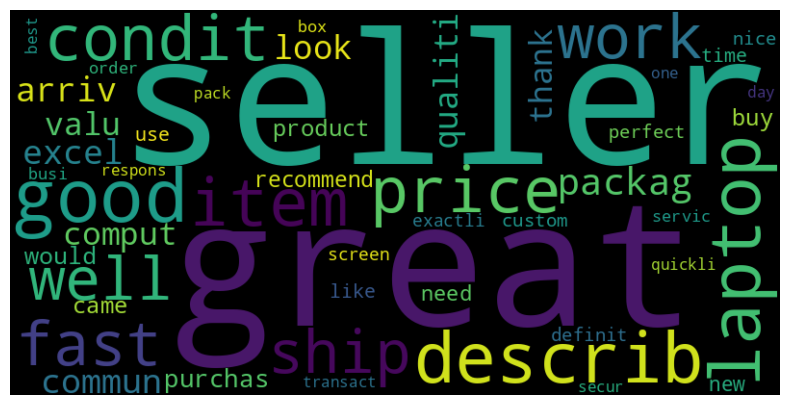

In [ ]:
import wordcloud
from wordcloud import WordCloud,STOPWORDS
wordcloud = WordCloud(width=800, height=400, max_words=50).generate_from_frequencies(freq_dict)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # No axes for the word cloud
plt.show()

In [ ]:
positive_words = set(opinion_lexicon.positive())
positive_word_list = [w for w in wordfreq if w in positive_words]

In [ ]:
positive_word_freq = {word: wordfreq[word] for word in positive_word_list}

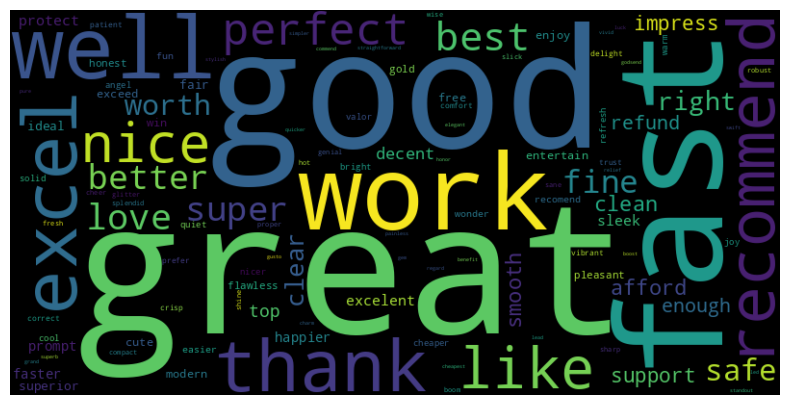

In [ ]:
wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(positive_word_freq)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # No axes for the word cloud
plt.show()

In [ ]:
negative_words = set(opinion_lexicon.negative())
negative_word_list = [w for w in wordfreq if w in negative_words]
negative_word_freq = {word: wordfreq[word] for word in negative_word_list}

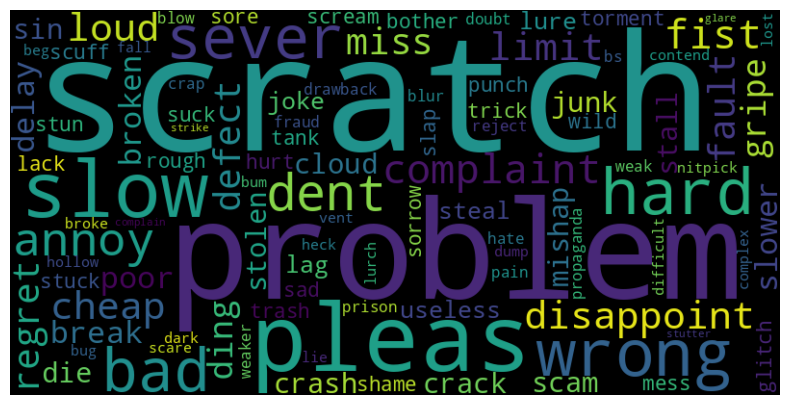

In [ ]:
wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(negative_word_freq)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # No axes for the word cloud
plt.show()

In [ ]:
def classify_sentiment(sentence):
    words = word_tokenize(sentence.lower())
    words_checked=[]
    s_word=[]
    for w in words:
      if w not in stop_words and w.isalpha():
        words_checked.append(w)
    for w in words_checked:
      s_word.append(ps.stem(w))
    positive_count = sum(1 for word in s_word if word in positive_words)
    negative_count = sum(1 for word in s_word if word in negative_words)
    if positive_count > negative_count:
        return 'Positive'
    elif negative_count > positive_count:
        return 'Negative'
    else:
        return 'Neutral'

In [ ]:
df['Sentiment']=df['Review'].apply((classify_sentiment))

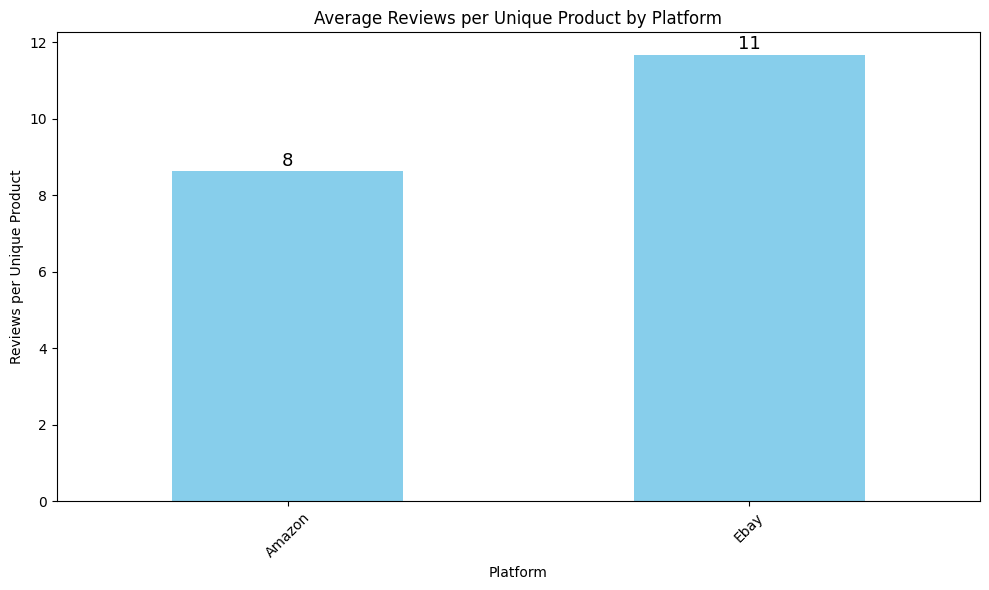

In [ ]:
total_reviews_per_platform = df.groupby('Platform')['Review'].count()
unique_products_per_platform = df.groupby('Platform')['Product Title'].nunique()
unique_products_per_platform
review_to_product_ratio = total_reviews_per_platform / unique_products_per_platform
plt.figure(figsize=(10, 6))
ax=review_to_product_ratio.plot(kind='bar', color='skyblue')
plt.title('Average Reviews per Unique Product by Platform')
plt.xlabel('Platform')
plt.ylabel('Reviews per Unique Product')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                xytext=(0, 1),  # 10 points vertical offset
                textcoords='offset points',
                ha='center', va='bottom', fontsize=13, color='black')
plt.tight_layout()
plt.show()

<ipython-input-50-0821b6ba51bf>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_reviews['Product Title'] = amazon_reviews['Product Title'].str[:15]


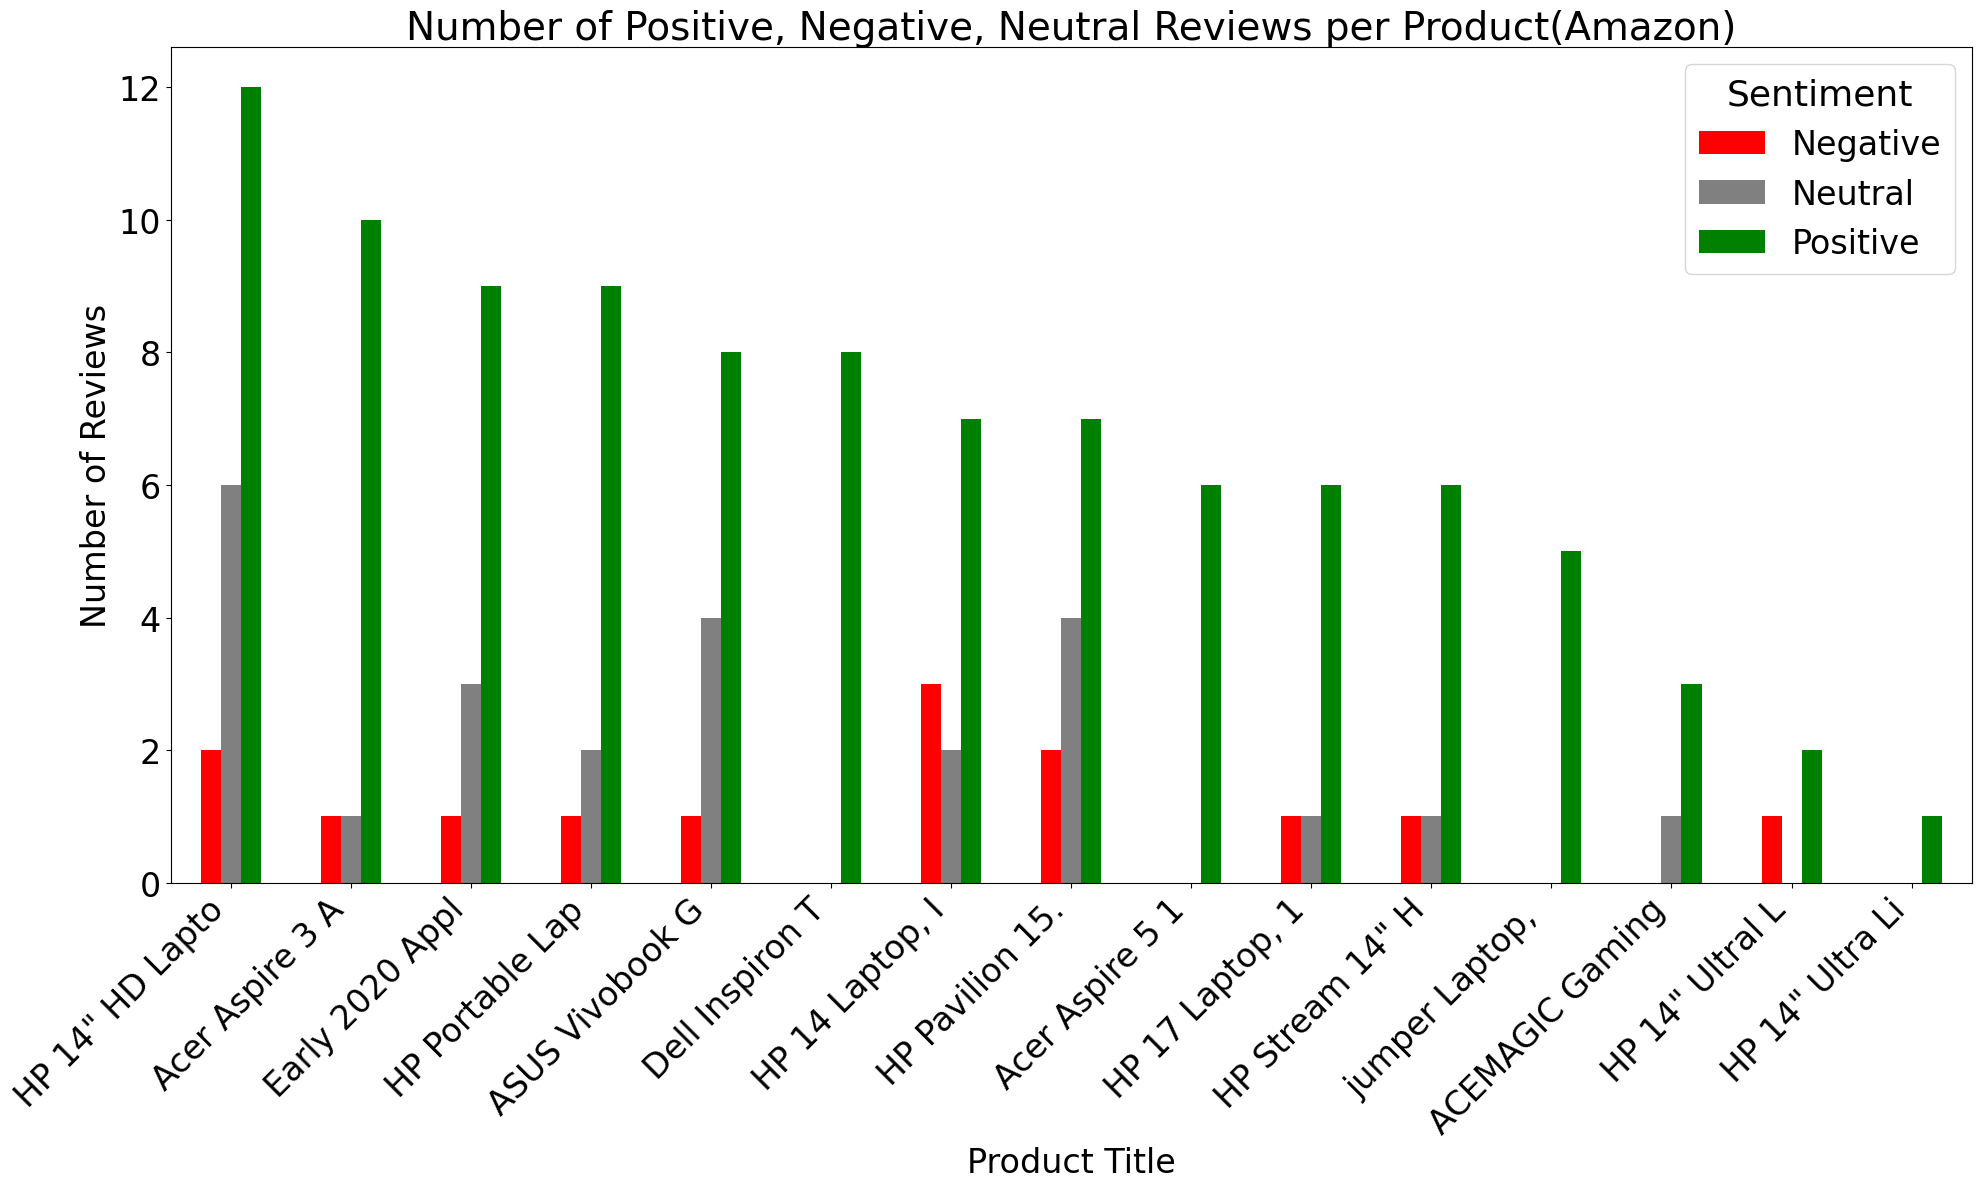

In [ ]:
amazon_reviews = df[df['Platform'] == 'Amazon']
amazon_reviews['Product Title'] = amazon_reviews['Product Title'].str[:15]
review_counts = amazon_reviews.groupby(['Product Title', 'Sentiment']).size().unstack(fill_value=0)
review_counts = review_counts.sort_values(by='Positive', ascending=False)
ax = review_counts.plot(kind='bar', figsize=(20, 12), stacked=False, color=['red', 'grey','green'])
ax.set_title('Number of Positive, Negative, Neutral Reviews per Product(Amazon)', fontsize=28)
ax.set_xlabel('Product Title', fontsize=24)
ax.set_ylabel('Number of Reviews', fontsize=24)
plt.xticks(rotation=45, ha="right", fontsize=24)
plt.yticks(fontsize=24)
plt.legend(title='Sentiment',loc='upper right',title_fontsize='26',fontsize=24)
plt.tight_layout()
plt.show()

<ipython-input-60-9bf6d26dd630>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ebay_reviews['Product Title'] = ebay_reviews['Product Title'].str[:15]


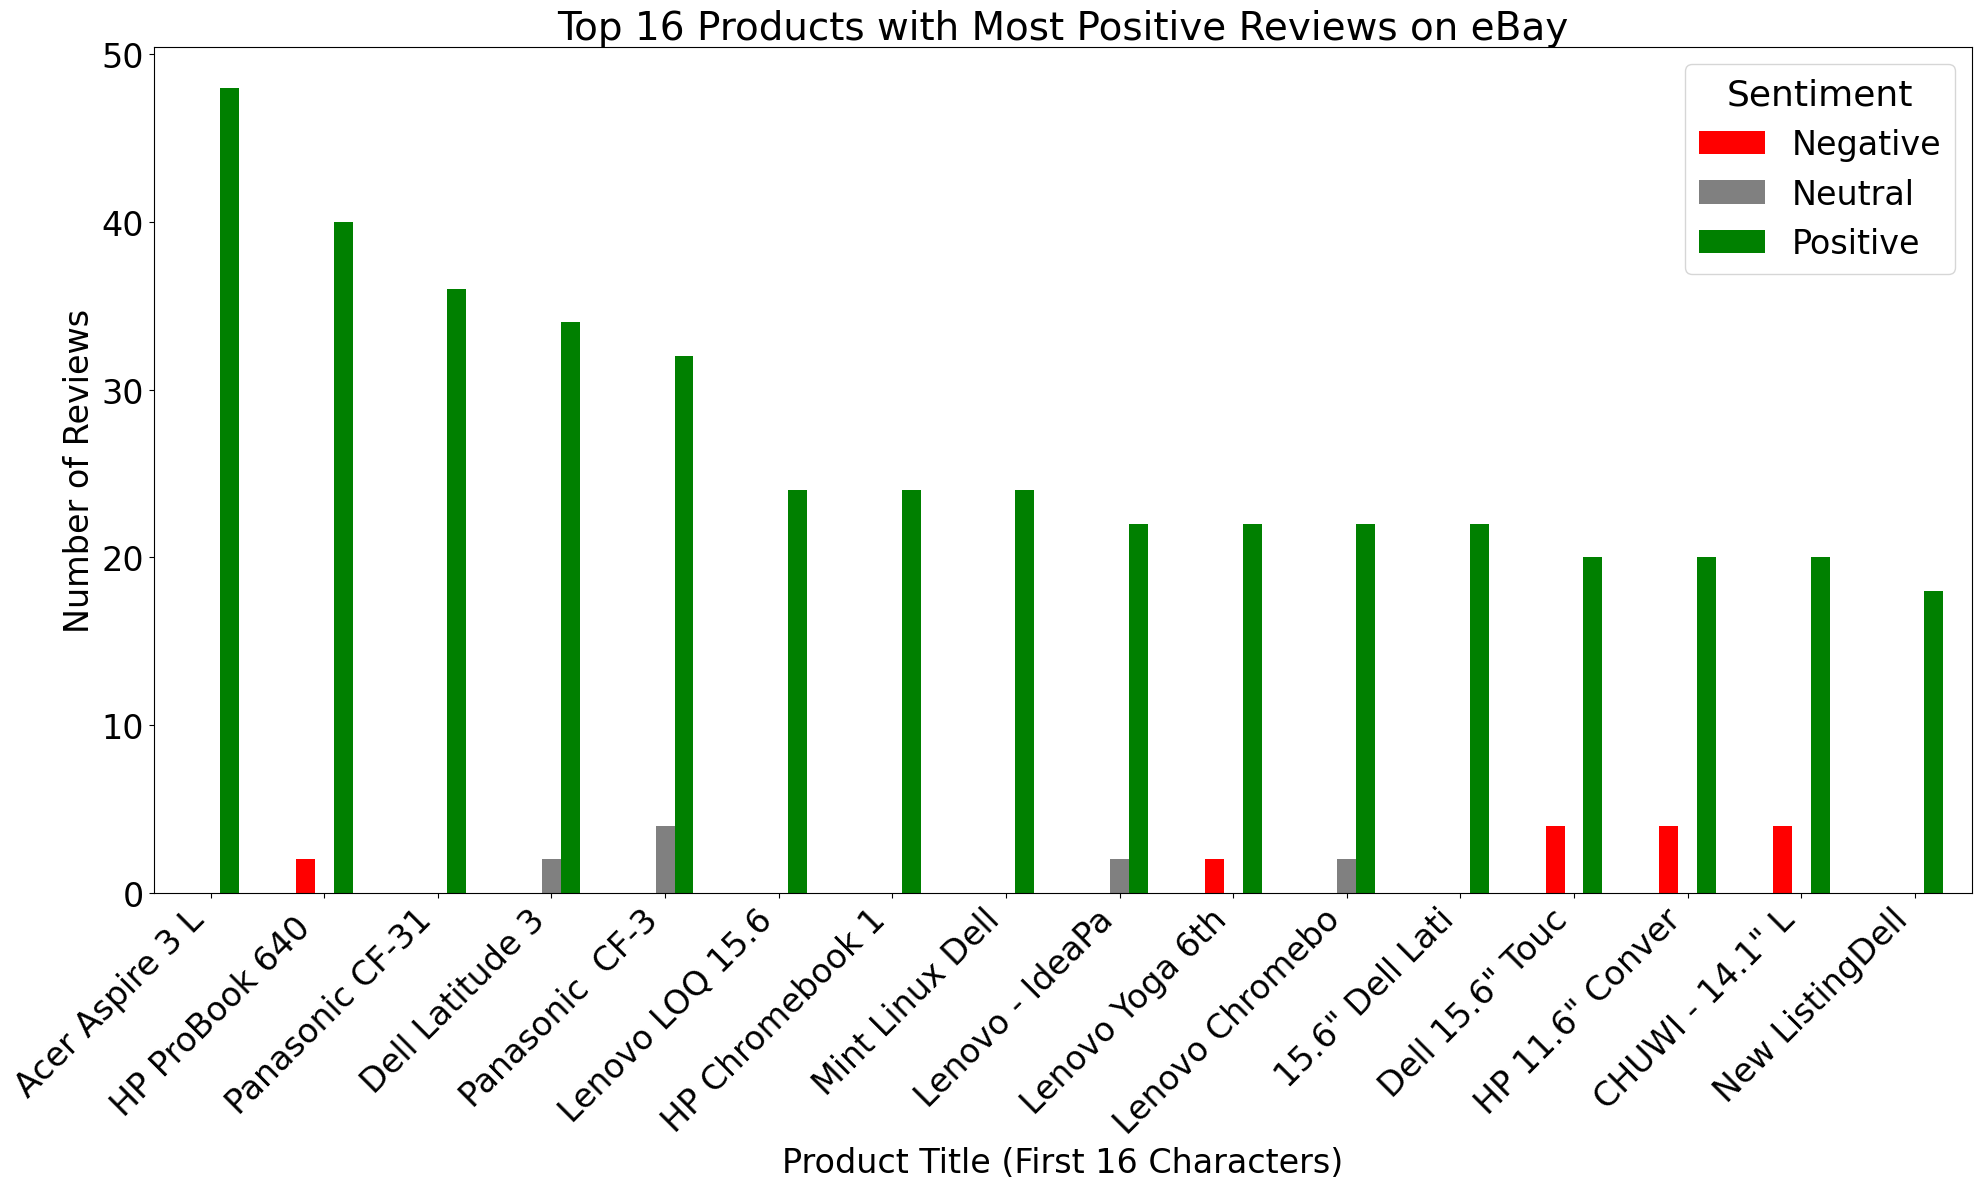

In [ ]:
ebay_reviews = df[df['Platform'] == 'Ebay']
ebay_reviews['Product Title'] = ebay_reviews['Product Title'].str[:15]
review_counts_ebay = ebay_reviews.groupby(['Product Title', 'Sentiment']).size().unstack(fill_value=0)
review_counts_ebay = review_counts_ebay.sort_values(by='Positive', ascending=False).head(16)
ax = review_counts_ebay.plot(kind='bar', figsize=(20, 12), stacked=False, color=['red', 'grey','green'])
ax.set_title('Top 16 Products with Most Positive Reviews on eBay', fontsize=28)
ax.set_xlabel('Product Title (First 16 Characters)', fontsize=24)
ax.set_ylabel('Number of Reviews', fontsize=24)
plt.xticks(rotation=45, ha="right", fontsize=24)
plt.yticks(fontsize=24)
plt.legend(title='Sentiment', loc='upper right', title_fontsize=26, fontsize=24)
plt.tight_layout()
plt.show()

<ipython-input-52-e5aaea154a2d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ebay_reviews['Product Title'] = ebay_reviews['Product Title'].str[:15]


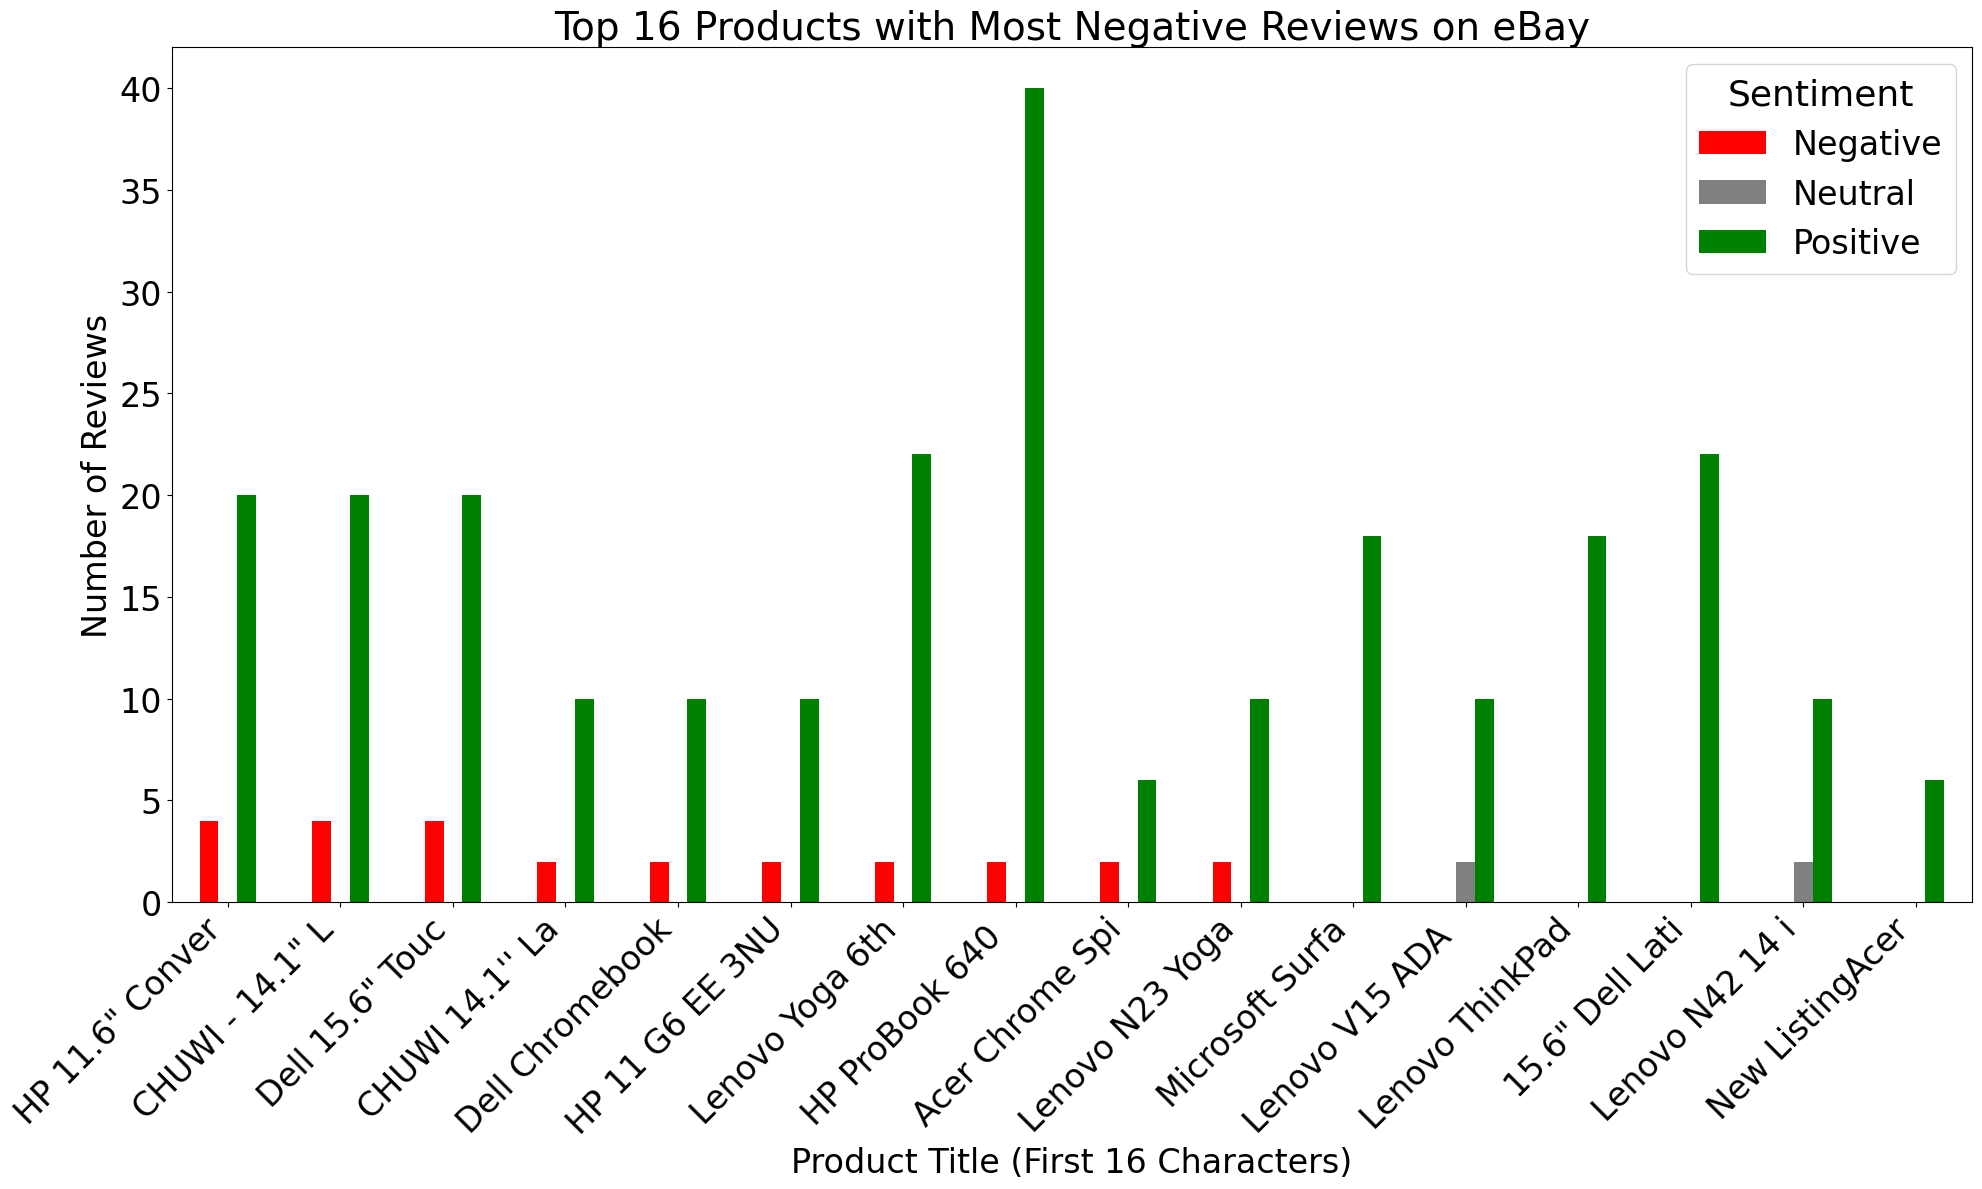

In [ ]:
ebay_reviews = df[df['Platform'] == 'Ebay']
ebay_reviews['Product Title'] = ebay_reviews['Product Title'].str[:15]
review_counts_ebay = ebay_reviews.groupby(['Product Title', 'Sentiment']).size().unstack(fill_value=0)
review_counts_ebay = review_counts_ebay.sort_values(by='Negative', ascending=False).head(16)
ax = review_counts_ebay.plot(kind='bar', figsize=(20, 12), stacked=False, color=['red', 'grey','green'])
ax.set_title('Top 16 Products with Most Negative Reviews on eBay', fontsize=28)
ax.set_xlabel('Product Title (First 16 Characters)', fontsize=24)
ax.set_ylabel('Number of Reviews', fontsize=24)
plt.xticks(rotation=45, ha="right", fontsize=24)
plt.yticks(fontsize=24)
plt.legend(title='Sentiment', loc='upper right', title_fontsize=26, fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
df['Tokenized_Review'] = df['Review'].apply(lambda x: word_tokenize(x.lower()))
df['Tokenized_Review'] = df['Tokenized_Review'].apply(lambda x: [w for w in x if w.isalpha() and w not in stop_words])
w2v_model = Word2Vec(df['Tokenized_Review'], vector_size=100, window=5, min_count=1, workers=4)

In [ ]:
w2v_model

In [ ]:
def get_avg_word_vec(tokens, model, vector_size):
    vec = np.zeros(vector_size)
    count = 0
    for word in tokens:
        if word in model.wv:
            vec += model.wv[word]
            count += 1
    if count != 0:
        vec /= count
    return vec

df['Word2Vec_Vector'] = df['Tokenized_Review'].apply(lambda x: get_avg_word_vec(x, w2v_model, 100))

X = np.array(df['Word2Vec_Vector'].tolist())
y = df['Sentiment'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Accuracy: 96.51%
